# 6.12 - CertCF boundary-biased latent anchor diagnostics

This notebook compares three fixed-budget CertCF anchor-selection rules on the Adult dataset:

- `kmedoids_x`: class-wise `k`-medoids in the original input space `X`
- `kmedoids_z`: class-wise `k`-medoids in the penultimate feature space `Z`
- `weighted_kmedoids_z`: a notebook-only latent weighted `k`-medoids heuristic that gives more importance to low-margin training points near the decision boundary

The CertCF atlas is still built and queried in the original input space. The only thing that changes is **which original training points are selected as anchors**.

For the weighted variant, the boundary bias is introduced through a weighted latent-space objective surrogate:

\[
\min_M \sum_i w_i \min_{m \in M} d(z_i, z_m), \qquad w_i = 1 + \lambda \, S_i^{\gamma}
\]

where `S_i` is a class-wise boundary score derived from the model-predicted class logit margin on the training set. In this first notebook pass, the selector is implemented as a weighted CLARA-style heuristic in latent space so we can test the idea before integrating it into the main codebase.


In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from torch.utils.data import TensorDataset

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from counterfactuals.benchmarks import create_default_registries
from counterfactuals.utils.clustering import select_prototype_indices
from notebooks.utils import setup_notebook_style
from scripts.benchmark import _build_query_tasks, _build_torch_model_from_checkpoint

setup_notebook_style()
np.set_printoptions(precision=4, suppress=True)


In [2]:
CONFIG_PATH = ROOT / 'configs/benchmarks/benchmark_meeting_all_200q.yaml'

DATASETS = ['adult']
K_GRID = [100, 200, 300, 500]
ANCHOR_SELECTION_METHODS = ['kmedoids_x', 'kmedoids_z', 'weighted_kmedoids_z']
SELECTION_LABELS = {
    'kmedoids_x': 'k-medoids in input space (X)',
    'kmedoids_z': 'k-medoids in penultimate space (Z)',
    'weighted_kmedoids_z': 'boundary-weighted k-medoids in penultimate space (Z)',
}
SELECTION_SPACE_LABELS = {
    'kmedoids_x': 'input_space',
    'kmedoids_z': 'latent_space',
    'weighted_kmedoids_z': 'latent_space_weighted',
}
LIRPA_METHOD = 'backward'
CERTCF_PARAM_OVERRIDES = {
    'eps_alpha': 0.45,
}
LOW_MARGIN_QUANTILE = 0.10
MAX_COVERAGE_POINTS_PER_CLASS = 4000
PILOT_N_QUERIES = 25
VISUAL_K = 200
VIS_POINTS_PER_CLASS = 1500
SEED = 42

BOUNDARY_SCORE_NAME = 'margin_sigmoid'
BOUNDARY_WEIGHT_STRENGTH = 4.0
BOUNDARY_WEIGHT_GAMMA = 2.0
WEIGHTED_UNIFORM_MIX = 0.15
WEIGHTED_SUBSET_FACTOR = 12
WEIGHTED_SUBSET_MAX = 6000
WEIGHTED_N_TRIALS = 5
WEIGHTED_TOP_FRACTION = 0.25

print(CONFIG_PATH)
print(DATASETS)
print(K_GRID)
print(ANCHOR_SELECTION_METHODS)
print(LIRPA_METHOD)
print(CERTCF_PARAM_OVERRIDES)
print({
    'boundary_score': BOUNDARY_SCORE_NAME,
    'weight_strength': BOUNDARY_WEIGHT_STRENGTH,
    'weight_gamma': BOUNDARY_WEIGHT_GAMMA,
    'weighted_subset_factor': WEIGHTED_SUBSET_FACTOR,
    'weighted_n_trials': WEIGHTED_N_TRIALS,
})


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/benchmark_meeting_all_200q.yaml
['adult']
[100, 200, 300, 500]
['kmedoids_x', 'kmedoids_z', 'weighted_kmedoids_z']
backward
{'eps_alpha': 0.45}
{'boundary_score': 'margin_sigmoid', 'weight_strength': 4.0, 'weight_gamma': 2.0, 'weighted_subset_factor': 12, 'weighted_n_trials': 5}


In [3]:

with CONFIG_PATH.open() as f:
    BENCHMARK_CFG = yaml.safe_load(f)

DATASET_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['datasets']}
SHARED_METHOD_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['methods']}
REGISTRIES = create_default_registries()

missing = sorted(set(DATASETS).difference(DATASET_CFGS))
if missing:
    raise ValueError(f'Unknown datasets in DATASETS: {missing}')


def _norm_to_cdist_metric(norm_value):
    if norm_value == 1:
        return 'cityblock'
    if norm_value == 2:
        return 'euclidean'
    if norm_value == np.inf:
        return 'chebyshev'
    raise ValueError(f'Unsupported norm for cdist conversion: {norm_value!r}')


def _merge_certcf_params(dataset_name):
    params = dict(SHARED_METHOD_CFGS['certcf'].get('params', {}))
    ds_overrides = DATASET_CFGS[dataset_name].get('method_overrides', {}).get('certcf', {})
    params.update(ds_overrides)
    params.update(CERTCF_PARAM_OVERRIDES)
    return params


def _resolve_lirpa_method(method_name):
    return str(method_name).strip().lower().replace('_', '-')


def _resolve_repo_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    candidates = [ROOT / path, Path.cwd() / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return (ROOT / path).resolve()


def _batched_logits(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            logits = module(x_batch).detach().cpu().numpy()
            outputs.append(logits)
    return np.concatenate(outputs, axis=0)


def _batched_penultimate_embeddings(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    if not hasattr(module, '__getitem__') or len(module) < 2:
        raise ValueError('Expected a sequential classifier with a final linear layer.')
    feature_extractor = module[:-1]
    final_linear = module[-1]
    if not isinstance(final_linear, torch.nn.Linear):
        raise ValueError('Expected the last classifier layer to be Linear.')

    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            z_batch = feature_extractor(x_batch).detach().cpu().numpy()
            outputs.append(z_batch)
    return np.concatenate(outputs, axis=0)


def _margin_scores(logits, y_ref):
    logits = np.asarray(logits, dtype=np.float64)
    y_ref = np.asarray(y_ref, dtype=np.int64)
    true_scores = logits[np.arange(len(y_ref)), y_ref]
    masked = logits.copy()
    masked[np.arange(len(y_ref)), y_ref] = -np.inf
    other_scores = masked.max(axis=1)
    return true_scores - other_scores


def _boundary_scores_from_margins(margins, y_ref):
    margins = np.asarray(margins, dtype=np.float64)
    y_ref = np.asarray(y_ref, dtype=np.int64)
    scores = np.zeros_like(margins, dtype=np.float64)
    for cls in np.unique(y_ref):
        idx = np.where(y_ref == int(cls))[0]
        cls_margin = margins[idx]
        med = float(np.median(cls_margin))
        mad = float(np.median(np.abs(cls_margin - med)))
        scale = max(mad * 1.4826, 1e-3)
        cls_scores = 1.0 / (1.0 + np.exp(cls_margin / scale))
        if np.max(cls_scores) > np.min(cls_scores):
            cls_scores = (cls_scores - cls_scores.min()) / (cls_scores.max() - cls_scores.min())
        scores[idx] = cls_scores
    return scores.astype(np.float32)


def _boundary_weight_vector(boundary_scores):
    boundary_scores = np.asarray(boundary_scores, dtype=np.float64)
    return 1.0 + BOUNDARY_WEIGHT_STRENGTH * np.power(np.clip(boundary_scores, 0.0, 1.0), BOUNDARY_WEIGHT_GAMMA)


def _split_indices_into_strata(cls_idx, margins):
    cls_idx = np.asarray(cls_idx, dtype=np.int64)
    ordered = cls_idx[np.argsort(margins[cls_idx], kind='stable')]
    splits = np.array_split(ordered, 3)
    return {
        'boundary': np.asarray(splits[0], dtype=np.int64),
        'intermediate': np.asarray(splits[1], dtype=np.int64),
        'interior': np.asarray(splits[2], dtype=np.int64),
    }


def _load_dataset_bundle(dataset_name):
    ds_cfg = DATASET_CFGS[dataset_name]
    dataset_params = dict(ds_cfg.get('dataset_params', {'data_dir': 'data/'}))
    dataset_params['data_dir'] = str(_resolve_repo_path(dataset_params.get('data_dir', 'data/')))
    dataset = REGISTRIES['dataset'].create(dataset_name, **dataset_params)
    dataset.load()

    x_train, y_train = dataset.get_train()
    x_test, y_test = dataset.get_test()
    model_cfg = ds_cfg['model']
    if model_cfg['name'] != 'tabular_classifier_ckpt':
        raise ValueError(f"This notebook only supports tabular checkpoint models, got {model_cfg['name']!r}.")

    model_params = dict(model_cfg.get('params', {}))
    model_params['checkpoint'] = str(_resolve_repo_path(model_params['checkpoint']))
    model = _build_torch_model_from_checkpoint(
        checkpoint=model_params['checkpoint'],
        device=model_params.get('device', 'cpu'),
        dataset_module=model_params.get('dataset_module', dataset_name),
        hidden_dims=list(model_params.get('hidden_dims', [32, 8])),
        dropout=float(model_params.get('dropout', 0.2)),
    )

    certcf_params = _merge_certcf_params(dataset_name)
    cert_norm = np.inf if str(certcf_params.get('norm', 2)).lower() in {'inf', 'infinity'} else int(certcf_params.get('norm', 2))
    distance_norm_raw = certcf_params.get('distance_norm', cert_norm)
    distance_norm = np.inf if str(distance_norm_raw).lower() in {'inf', 'infinity'} else int(distance_norm_raw)
    query_method = str(certcf_params.get('query_method', 'sorted')).lower()
    spec = getattr(dataset, 'spec', None)
    ohe_slices = list(spec.categorical_slices) if spec is not None and len(spec.categorical_slices) else None

    x_train = np.asarray(x_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int64)
    x_test = np.asarray(x_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.int64)
    y_train_pred = np.asarray(model.predict(x_train), dtype=np.int64)

    logits = _batched_logits(model, x_train)
    margins = _margin_scores(logits, y_train_pred)
    boundary_scores = _boundary_scores_from_margins(margins, y_train_pred)
    z_train = _batched_penultimate_embeddings(model, x_train)

    return {
        'dataset_name': dataset_name,
        'dataset': dataset,
        'spec': spec,
        'x_train': x_train,
        'y_train': y_train,
        'y_train_pred': y_train_pred,
        'z_train': np.asarray(z_train, dtype=np.float32),
        'x_test': x_test,
        'y_test': y_test,
        'model': model,
        'model_cfg': model_cfg,
        'certcf_params': certcf_params,
        'cert_norm': cert_norm,
        'distance_norm': distance_norm,
        'query_method': query_method,
        'ohe_slices': ohe_slices,
        'margin_scores': margins.astype(np.float32),
        'boundary_scores': boundary_scores.astype(np.float32),
        'class_labels': [int(v) for v in np.unique(y_train_pred)],
        'prototype_indices_cache': {},
        'atlas_cache': {},
        'class_strata_cache': {},
        'eval_indices_cache': {},
    }


def _get_class_strata(bundle, class_label):
    cache = bundle['class_strata_cache']
    class_label = int(class_label)
    if class_label in cache:
        return cache[class_label]
    cls_idx = np.where(bundle['y_train_pred'] == class_label)[0]
    strata = _split_indices_into_strata(cls_idx, bundle['margin_scores'])
    cache[class_label] = strata
    return strata


def _selector_space(bundle, selection_method):
    if selection_method == 'kmedoids_x':
        return bundle['x_train']
    if selection_method in {'kmedoids_z', 'weighted_kmedoids_z'}:
        return bundle['z_train']
    raise ValueError(f'Unknown selection_method: {selection_method!r}')


def _select_within_subset(space_subset, k):
    k = min(int(k), len(space_subset))
    if k <= 0:
        return np.array([], dtype=np.int64)
    if k == len(space_subset):
        return np.arange(len(space_subset), dtype=np.int64)
    return np.asarray(
        select_prototype_indices(space_subset, k=k, method='kmedoids', random_state=SEED),
        dtype=np.int64,
    )


def _weighted_latent_kmedoids_indices(space_subset, boundary_scores, k, *, random_state):
    k = min(int(k), len(space_subset))
    if k <= 0:
        return np.array([], dtype=np.int64)
    if k == len(space_subset):
        return np.arange(len(space_subset), dtype=np.int64)

    X = np.asarray(space_subset, dtype=np.float32)
    weights = _boundary_weight_vector(boundary_scores)
    probs = weights / weights.sum()
    probs = (1.0 - WEIGHTED_UNIFORM_MIX) * probs + WEIGHTED_UNIFORM_MIX / len(X)

    subset_size = min(len(X), max(k, min(WEIGHTED_SUBSET_MAX, int(np.ceil(WEIGHTED_SUBSET_FACTOR * k)))))
    top_keep = min(len(X), min(subset_size, max(10, int(np.ceil(WEIGHTED_TOP_FRACTION * k)))))
    top_idx = np.argsort(-weights, kind='stable')[:top_keep].astype(np.int64)
    best_global = None
    best_obj = np.inf
    full_idx = np.arange(len(X), dtype=np.int64)

    for trial in range(max(1, int(WEIGHTED_N_TRIALS))):
        trial_rng = np.random.default_rng(int(random_state) + 1_000 * (trial + 1))
        if subset_size > len(top_idx):
            remaining = full_idx[~np.isin(full_idx, top_idx)]
            if len(remaining) <= subset_size - len(top_idx):
                sampled_rest = remaining
            else:
                rem_probs = probs[remaining]
                rem_probs = rem_probs / rem_probs.sum()
                sampled_rest = np.asarray(
                    trial_rng.choice(remaining, size=subset_size - len(top_idx), replace=False, p=rem_probs),
                    dtype=np.int64,
                )
        else:
            sampled_rest = np.array([], dtype=np.int64)

        subset_idx = np.unique(np.concatenate([top_idx, sampled_rest]).astype(np.int64))
        if len(subset_idx) < k:
            fill = full_idx[~np.isin(full_idx, subset_idx)][: k - len(subset_idx)]
            subset_idx = np.concatenate([subset_idx, fill]).astype(np.int64)

        local_idx = np.asarray(
            select_prototype_indices(X[subset_idx], k=k, method='kmedoids', random_state=int(random_state) + trial),
            dtype=np.int64,
        )
        global_idx = subset_idx[local_idx]
        min_dists = cdist(X, X[global_idx], metric='euclidean').min(axis=1)
        objective = float(np.average(min_dists, weights=weights))
        if objective < best_obj:
            best_obj = objective
            best_global = global_idx

    return np.asarray(best_global, dtype=np.int64)


def _get_prototype_indices(bundle, selection_method, k):
    cache = bundle['prototype_indices_cache']
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    selector_space = _selector_space(bundle, selection_method)
    selected = []
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train_pred'] == class_label)[0]
        k_cls = min(int(k), len(cls_idx))
        if selection_method == 'weighted_kmedoids_z':
            local_idx = _weighted_latent_kmedoids_indices(
                selector_space[cls_idx],
                bundle['boundary_scores'][cls_idx],
                k_cls,
                random_state=SEED + int(class_label) * 1_003 + int(k) * 31,
            )
        else:
            local_idx = _select_within_subset(selector_space[cls_idx], k_cls)
        selected.append(cls_idx[local_idx])

    absolute_idx = np.concatenate(selected).astype(np.int64)
    cache[cache_key] = absolute_idx
    return absolute_idx


def _get_eval_indices(bundle, class_label, max_points=MAX_COVERAGE_POINTS_PER_CLASS):
    cache_key = (int(class_label), int(max_points) if max_points is not None else None)
    cache = bundle['eval_indices_cache']
    if cache_key in cache:
        return cache[cache_key]

    cls_idx = np.where(bundle['y_train_pred'] == int(class_label))[0]
    if max_points is not None and len(cls_idx) > max_points:
        rng = np.random.default_rng(SEED + 10_000 + int(class_label))
        eval_idx = np.sort(rng.choice(cls_idx, size=max_points, replace=False))
    else:
        eval_idx = cls_idx
    cache[cache_key] = eval_idx
    return eval_idx


def _build_certcf_atlas(bundle, selection_method, k):
    cache = bundle['atlas_cache']
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    x_proto = bundle['x_train'][selected_idx]
    y_proto = bundle['y_train_pred'][selected_idx]
    params = bundle['certcf_params']

    atlas = CertCFAtlas(
        model=bundle['model'].model,
        dataset=TensorDataset(torch.from_numpy(x_proto).float(), torch.from_numpy(y_proto).long()),
        device=bundle['model'].device,
        cnn=False,
        norm=bundle['cert_norm'],
        distance_norm=bundle['distance_norm'],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25)))),
        batch_size=int(params.get('batch_size', 256)),
        ohe_slices=bundle['ohe_slices'],
        default_query_method=bundle['query_method'],
        solver_maxiter=int(params.get('solver_maxiter', 500)),
        lirpa_method=_resolve_lirpa_method(LIRPA_METHOD),
    )

    t0 = time.perf_counter()
    atlas.build(verbose=False)
    build_time_s = time.perf_counter() - t0
    cache[cache_key] = (atlas, build_time_s, selected_idx)
    return cache[cache_key]


def _summary_stats(values):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return {
            'n_points': 0,
            'mean_distance': np.nan,
            'median_distance': np.nan,
            'p90_distance': np.nan,
            'p95_distance': np.nan,
        }
    return {
        'n_points': int(len(values)),
        'mean_distance': float(np.mean(values)),
        'median_distance': float(np.median(values)),
        'p90_distance': float(np.quantile(values, 0.90)),
        'p95_distance': float(np.quantile(values, 0.95)),
    }


def _selection_summary_rows(bundle, selection_method, k):
    y_train = bundle['y_train_pred']
    margins = bundle['margin_scores']
    boundary_scores = bundle['boundary_scores']
    selected_idx = _get_prototype_indices(bundle, selection_method, k)

    rows = []
    total_counts = {'boundary': 0, 'intermediate': 0, 'interior': 0}
    for class_label in bundle['class_labels']:
        strata = _get_class_strata(bundle, int(class_label))
        class_selected = selected_idx[y_train[selected_idx] == int(class_label)]
        row = {
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_selected': int(len(class_selected)),
            'selected_margin_mean': float(np.mean(margins[class_selected])) if len(class_selected) else np.nan,
            'selected_margin_median': float(np.median(margins[class_selected])) if len(class_selected) else np.nan,
            'selected_boundary_score_mean': float(np.mean(boundary_scores[class_selected])) if len(class_selected) else np.nan,
            'selected_boundary_score_median': float(np.median(boundary_scores[class_selected])) if len(class_selected) else np.nan,
            'selected_boundary_score_p90': float(np.quantile(boundary_scores[class_selected], 0.90)) if len(class_selected) else np.nan,
        }
        for name in ['boundary', 'intermediate', 'interior']:
            count = int(np.isin(class_selected, strata[name]).sum())
            row[f'n_{name}'] = count
            total_counts[name] += count
        rows.append(row)

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_selected': int(len(selected_idx)),
        'selected_margin_mean': float(np.mean(margins[selected_idx])) if len(selected_idx) else np.nan,
        'selected_margin_median': float(np.median(margins[selected_idx])) if len(selected_idx) else np.nan,
        'selected_boundary_score_mean': float(np.mean(boundary_scores[selected_idx])) if len(selected_idx) else np.nan,
        'selected_boundary_score_median': float(np.median(boundary_scores[selected_idx])) if len(selected_idx) else np.nan,
        'selected_boundary_score_p90': float(np.quantile(boundary_scores[selected_idx], 0.90)) if len(selected_idx) else np.nan,
        **{f'n_{name}': int(total_counts[name]) for name in ['boundary', 'intermediate', 'interior']},
    })
    return rows


def _prototype_distance_rows(bundle, selection_method, k):
    y_train = bundle['y_train_pred']
    margins = bundle['margin_scores']
    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    selector_space = _selector_space(bundle, selection_method)
    metric = _norm_to_cdist_metric(bundle['cert_norm'])

    rows = []
    overall_dists = []
    overall_low_margin_dists = []

    for class_label in bundle['class_labels']:
        cls_idx = np.where(y_train == class_label)[0]
        proto_idx = selected_idx[y_train[selected_idx] == class_label]
        cls_dists = cdist(selector_space[cls_idx], selector_space[proto_idx], metric=metric).min(axis=1)
        overall_dists.append(cls_dists)

        class_threshold = np.quantile(margins[cls_idx], LOW_MARGIN_QUANTILE)
        low_margin_mask = margins[cls_idx] <= class_threshold
        low_margin_dists = cls_dists[low_margin_mask]
        overall_low_margin_dists.append(low_margin_dists)

        for subset_name, subset_dists in [('all', cls_dists), ('low_margin', low_margin_dists)]:
            row = {
                'dataset': bundle['dataset_name'],
                'selection_method': selection_method,
                'selection_label': SELECTION_LABELS[selection_method],
                'selection_space': SELECTION_SPACE_LABELS[selection_method],
                'class_label': int(class_label),
                'k_per_class': int(k),
                'subset': subset_name,
                'n_prototypes_for_class': int(len(proto_idx)),
            }
            row.update(_summary_stats(subset_dists))
            rows.append(row)

    for subset_name, pieces in [('all', overall_dists), ('low_margin', overall_low_margin_dists)]:
        merged = np.concatenate([piece for piece in pieces if len(piece) > 0]) if pieces else np.array([], dtype=np.float64)
        row = {
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': 'overall',
            'k_per_class': int(k),
            'subset': subset_name,
            'n_prototypes_for_class': int(k),
        }
        row.update(_summary_stats(merged))
        rows.append(row)

    return rows


def _certified_membership_mask(atlas, class_label, x_eval):
    x_eval = np.asarray(x_eval, dtype=np.float64)
    mask = np.zeros(len(x_eval), dtype=bool)
    bd = atlas.bounds[int(class_label)]
    for i, x in enumerate(x_eval):
        for anchor_idx in range(len(bd['X'])):
            nominal_ok, _ = atlas._polytope_membership_for_anchor(
                np.asarray(x, dtype=np.float64),
                bd,
                anchor_idx,
                delta=0.0,
                robust_norm=atlas.norm,
            )
            if nominal_ok:
                mask[i] = True
                break
    return mask


def _certified_cover_counts(atlas, class_label, x_eval):
    x_eval = np.asarray(x_eval, dtype=np.float64)
    bd = atlas.bounds[int(class_label)]
    counts = np.zeros(len(x_eval), dtype=np.int64)
    for anchor_idx in range(len(bd['X'])):
        for i, x in enumerate(x_eval):
            nominal_ok, _ = atlas._polytope_membership_for_anchor(
                np.asarray(x, dtype=np.float64),
                bd,
                anchor_idx,
                delta=0.0,
                robust_norm=atlas.norm,
            )
            if nominal_ok:
                counts[i] += 1
    return counts


def _coverage_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_covered = 0

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        covered = _certified_membership_mask(atlas, int(class_label), x_train[eval_idx])
        total_eval += int(len(eval_idx))
        total_covered += int(covered.sum())
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'n_covered': int(covered.sum()),
            'coverage_rate': float(covered.mean()),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'n_covered': int(total_covered),
        'coverage_rate': float(total_covered / total_eval) if total_eval else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _overlap_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_cover_counts = []

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        cover_counts = _certified_cover_counts(atlas, int(class_label), x_train[eval_idx])
        covered_mask = cover_counts > 0
        multi_mask = cover_counts >= 2
        overlap_excess = np.maximum(cover_counts - 1, 0)

        total_eval += int(len(eval_idx))
        total_cover_counts.append(cover_counts)
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'coverage_rate': float(covered_mask.mean()) if len(cover_counts) else np.nan,
            'multi_cover_rate': float(multi_mask.mean()) if len(cover_counts) else np.nan,
            'mean_cover_count': float(np.mean(cover_counts)) if len(cover_counts) else np.nan,
            'mean_cover_count_if_covered': float(np.mean(cover_counts[covered_mask])) if covered_mask.any() else np.nan,
            'mean_overlap_excess': float(np.mean(overlap_excess)) if len(cover_counts) else np.nan,
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    merged = np.concatenate(total_cover_counts) if total_cover_counts else np.array([], dtype=np.int64)
    covered_mask = merged > 0
    multi_mask = merged >= 2
    overlap_excess = np.maximum(merged - 1, 0)
    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'coverage_rate': float(covered_mask.mean()) if len(merged) else np.nan,
        'multi_cover_rate': float(multi_mask.mean()) if len(merged) else np.nan,
        'mean_cover_count': float(np.mean(merged)) if len(merged) else np.nan,
        'mean_cover_count_if_covered': float(np.mean(merged[covered_mask])) if covered_mask.any() else np.nan,
        'mean_overlap_excess': float(np.mean(overlap_excess)) if len(merged) else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _pilot_query_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    query_indices, y_true, y_orig, target_classes = _build_query_tasks(
        dataset_name=bundle['dataset_name'],
        x_test=bundle['x_test'],
        y_test=bundle['y_test'],
        model=bundle['model'],
        sampling_cfg={'n_queries': int(PILOT_N_QUERIES)},
        rng=np.random.default_rng(SEED),
    )

    if target_classes is None:
        n_classes = int(bundle['model'].predict_proba(bundle['x_test'][:1]).shape[1])
        if n_classes != 2:
            raise ValueError(
                f"Pilot query analysis requires explicit target classes for non-binary dataset {bundle['dataset_name']!r}."
            )
        target_classes = 1 - np.asarray(y_orig, dtype=np.int64)

    rows = []
    for query_idx, y_true_i, y_orig_i, target_class in zip(query_indices, y_true, y_orig, target_classes):
        x_query = bundle['x_test'][query_idx]
        result = atlas.find_counterfactual(
            x_query=x_query,
            target_class=int(target_class),
            method=bundle['query_method'],
        )
        x_cf = np.asarray(result.x_cf, dtype=np.float32) if result.success and result.x_cf is not None else None
        l1_distance = float(np.linalg.norm(x_cf - x_query, ord=1)) if x_cf is not None else np.nan
        l2_distance = float(np.linalg.norm(x_cf - x_query, ord=2)) if x_cf is not None else np.nan
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'k_per_class': int(k),
            'query_idx': int(query_idx),
            'y_true': int(y_true_i),
            'y_orig': int(y_orig_i),
            'target_class': int(target_class),
            'success': bool(result.success),
            'distance': float(result.distance) if result.success else np.nan,
            'l1_distance': l1_distance,
            'l2_distance': l2_distance,
            'query_time_ms': float(result.profiling.get('total_time_ms', np.nan)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })
    return rows


def _make_metric_table(selection_overall, compression_overall, coverage_overall, overlap_overall, pilot_summary):
    compression_pivot = compression_overall[
        ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'subset', 'p95_distance', 'mean_distance']
    ].pivot(
        index=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
        columns='subset',
        values=['p95_distance', 'mean_distance'],
    ).reset_index()
    compression_pivot.columns = [
        '_'.join([str(x) for x in col if x != '']).strip('_') if isinstance(col, tuple) else col
        for col in compression_pivot.columns
    ]

    metric_table = (
        selection_overall[[
            'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
            'selected_margin_mean', 'selected_margin_median',
            'selected_boundary_score_mean', 'selected_boundary_score_median', 'selected_boundary_score_p90',
            'n_boundary', 'n_intermediate', 'n_interior', 'n_selected'
        ]]
        .merge(
            coverage_overall[['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'coverage_rate']],
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            overlap_overall[['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'multi_cover_rate', 'mean_overlap_excess']],
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            compression_pivot,
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            pilot_summary[[
                'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
                'success_rate', 'mean_distance', 'median_distance', 'mean_query_time_ms', 'median_query_time_ms', 'build_time_s'
            ]].rename(columns={
                'mean_distance': 'pilot_mean_distance',
                'median_distance': 'pilot_median_distance',
            }),
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
    )
    metric_table['boundary_share'] = metric_table['n_boundary'] / metric_table['n_selected']
    return metric_table


def _make_delta_table(metric_table, baseline_method='kmedoids_x'):
    baseline = metric_table[metric_table['selection_method'] == baseline_method].copy()
    variants = metric_table[metric_table['selection_method'] != baseline_method].copy()
    merged = baseline.merge(variants, on=['dataset', 'k_per_class'], suffixes=('_baseline', '_variant'))
    delta_cols = [
        'selected_margin_mean', 'selected_boundary_score_mean', 'boundary_share',
        'coverage_rate', 'multi_cover_rate', 'mean_overlap_excess',
        'mean_distance_all', 'p95_distance_all', 'mean_distance_low_margin', 'p95_distance_low_margin',
        'success_rate', 'pilot_mean_distance', 'pilot_median_distance', 'mean_query_time_ms', 'median_query_time_ms', 'build_time_s',
    ]
    for col in delta_cols:
        merged[f'delta_{col}'] = merged[f'{col}_variant'] - merged[f'{col}_baseline']
    return merged


def _sample_support_indices(bundle, n_per_class, seed_offset=0):
    rng = np.random.default_rng(SEED + int(seed_offset))
    pieces = []
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train_pred'] == int(class_label))[0]
        take = min(int(n_per_class), len(cls_idx))
        if take == len(cls_idx):
            sampled = cls_idx
        else:
            sampled = np.sort(rng.choice(cls_idx, size=take, replace=False))
        pieces.append(sampled)
    return np.concatenate(pieces).astype(np.int64)


def _plot_support_with_anchors(ax, support_coords, support_labels, anchor_coords, anchor_labels, title):
    support_labels = np.asarray(support_labels, dtype=np.int64)
    anchor_labels = np.asarray(anchor_labels, dtype=np.int64)
    for class_label in np.unique(support_labels):
        mask = support_labels == int(class_label)
        ax.scatter(
            support_coords[mask, 0], support_coords[mask, 1],
            s=18, alpha=0.18, label=f'class {int(class_label)} support' if title.endswith('(X)') else None,
        )
    for class_label in np.unique(anchor_labels):
        mask = anchor_labels == int(class_label)
        ax.scatter(
            anchor_coords[mask, 0], anchor_coords[mask, 1],
            s=60, edgecolor='black', linewidth=0.6, alpha=0.95,
            label=f'class {int(class_label)} anchors' if title.endswith('(X)') else None,
        )
    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')


def _plot_anchor_views(bundle, visual_k):
    support_idx = _sample_support_indices(bundle, n_per_class=VIS_POINTS_PER_CLASS, seed_offset=777)
    support_x = bundle['x_train'][support_idx]
    support_z = bundle['z_train'][support_idx]
    support_y = bundle['y_train_pred'][support_idx]

    input_pca = PCA(n_components=2, random_state=SEED)
    input_support_coords = input_pca.fit_transform(support_x)

    latent_pca = PCA(n_components=2, random_state=SEED)
    latent_support_coords = latent_pca.fit_transform(support_z)

    fig, axes = plt.subplots(2, len(ANCHOR_SELECTION_METHODS), figsize=(6 * len(ANCHOR_SELECTION_METHODS), 10))
    if len(ANCHOR_SELECTION_METHODS) == 1:
        axes = np.asarray(axes).reshape(2, 1)

    for col, selection_method in enumerate(ANCHOR_SELECTION_METHODS):
        selected_idx = _get_prototype_indices(bundle, selection_method, visual_k)
        anchor_y = bundle['y_train_pred'][selected_idx]
        input_anchor_coords = input_pca.transform(bundle['x_train'][selected_idx])
        latent_anchor_coords = latent_pca.transform(bundle['z_train'][selected_idx])

        _plot_support_with_anchors(
            axes[0, col],
            support_coords=input_support_coords,
            support_labels=support_y,
            anchor_coords=input_anchor_coords,
            anchor_labels=anchor_y,
            title=f'Input PCA - {SELECTION_LABELS[selection_method]}',
        )
        _plot_support_with_anchors(
            axes[1, col],
            support_coords=latent_support_coords,
            support_labels=support_y,
            anchor_coords=latent_anchor_coords,
            anchor_labels=anchor_y,
            title=f'Latent PCA - {SELECTION_LABELS[selection_method]}',
        )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=min(4, len(handles)), frameon=False)
    fig.suptitle(f'Anchor layouts at k={visual_k}', y=1.02)
    fig.tight_layout()
    plt.show()


In [4]:
bundles = {dataset_name: _load_dataset_bundle(dataset_name) for dataset_name in DATASETS}

overview_rows = []
for dataset_name, bundle in bundles.items():
    true_class_counts = pd.Series(bundle['y_train']).value_counts().sort_index().to_dict()
    pred_class_counts = pd.Series(bundle['y_train_pred']).value_counts().sort_index().to_dict()
    overview_rows.append({
        'dataset': dataset_name,
        'n_train': int(len(bundle['x_train'])),
        'n_test': int(len(bundle['x_test'])),
        'train_true_classes': true_class_counts,
        'train_pred_classes': pred_class_counts,
        'input_dim': int(bundle['x_train'].shape[1]),
        'latent_dim': int(bundle['z_train'].shape[1]),
        'cert_norm': bundle['cert_norm'],
        'distance_norm': bundle['distance_norm'],
        'eps_alpha': float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25))),
        'query_method': bundle['query_method'],
        'lirpa_method': _resolve_lirpa_method(LIRPA_METHOD),
        'selection_methods': ', '.join(SELECTION_LABELS[name] for name in ANCHOR_SELECTION_METHODS),
    })

display(pd.DataFrame(overview_rows))


,dataset,n_train,n_test,train_true_classes,train_pred_classes,input_dim,latent_dim,cert_norm,distance_norm,eps_alpha,query_method,lirpa_method,selection_methods
0,adult,36178,4522,"{0: 27224, 1: 8954}","{0: 28458, 1: 7720}",104,8,1,1,0.45,sorted,backward,"k-medoids in input space (X), k-medoids in pen..."


## 1. Boundary Score And Anchor Selection Summary

This section checks whether the weighted latent selector actually moves anchor mass toward low-margin regions.

The boundary score is derived from the model-predicted class logit margin on the training set, transformed class-wise so that values near `1` indicate points closer to the decision boundary and values near `0` indicate points deeper in the class interior.


,dataset,class_label,n_points,margin_mean,margin_median,boundary_score_mean,boundary_score_median,boundary_score_p90
0,adult,0,28458,3.315552,2.971452,0.497636,0.476108,0.895012
1,adult,1,7720,1.871921,0.889060,0.459924,0.455781,0.874127


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_selected,selected_margin_mean,selected_margin_median,selected_boundary_score_mean,selected_boundary_score_median,selected_boundary_score_p90,n_boundary,n_intermediate,n_interior,boundary_share
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,200,1.426396,1.011643,0.576186,0.574682,0.883009,89,87,24,0.445000
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,200,2.174452,1.706281,0.458792,0.454514,0.602518,17,165,18,0.085000
26,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,100,200,1.402810,0.981280,0.625641,0.632440,0.799938,90,103,7,0.450000
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,400,1.488710,1.011519,0.565539,0.557554,0.873250,177,161,62,0.442500
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,400,2.082378,1.526386,0.455591,0.452097,0.544357,21,359,20,0.052500
29,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,200,400,1.318814,1.063130,0.617541,0.624004,0.743869,178,210,12,0.445000
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,600,1.420318,0.996046,0.581932,0.581143,0.882315,277,247,76,0.461667
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,600,2.056416,1.610333,0.452552,0.450433,0.517520,24,556,20,0.040000
32,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,300,600,1.307165,1.000481,0.602866,0.607777,0.751015,224,363,13,0.373333
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,1000,1.451220,0.996452,0.576428,0.581656,0.882442,464,385,151,0.464000


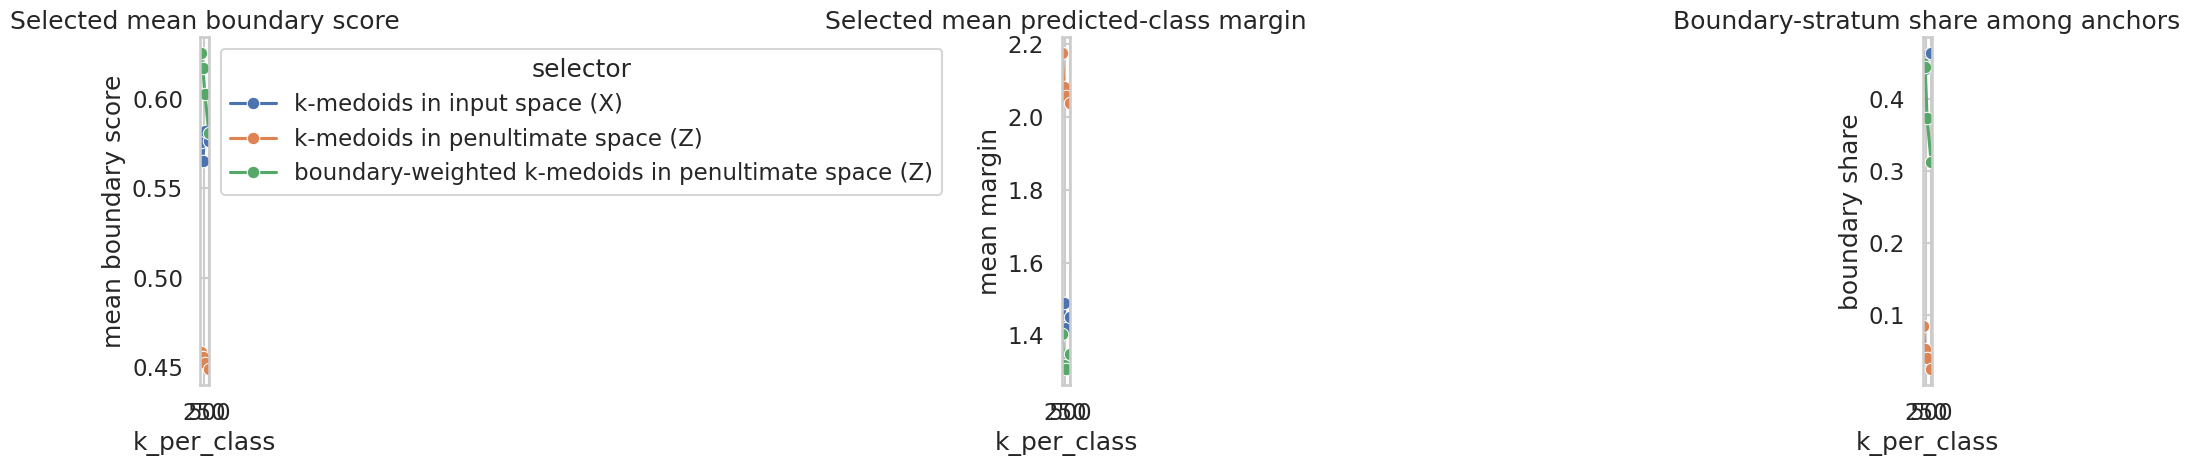

In [5]:
boundary_rows = []
for dataset_name, bundle in bundles.items():
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train_pred'] == int(class_label))[0]
        boundary_rows.append({
            'dataset': dataset_name,
            'class_label': int(class_label),
            'n_points': int(len(cls_idx)),
            'margin_mean': float(np.mean(bundle['margin_scores'][cls_idx])),
            'margin_median': float(np.median(bundle['margin_scores'][cls_idx])),
            'boundary_score_mean': float(np.mean(bundle['boundary_scores'][cls_idx])),
            'boundary_score_median': float(np.median(bundle['boundary_scores'][cls_idx])),
            'boundary_score_p90': float(np.quantile(bundle['boundary_scores'][cls_idx], 0.90)),
        })

display(pd.DataFrame(boundary_rows))

selection_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            selection_rows.extend(_selection_summary_rows(bundle, selection_method, k))

selection_df = pd.DataFrame(selection_rows)
selection_overall = selection_df[selection_df['class_label'].eq('overall')].copy()
selection_overall['boundary_share'] = selection_overall['n_boundary'] / selection_overall['n_selected']
display(selection_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharex=True)
sns.lineplot(data=selection_overall, x='k_per_class', y='selected_boundary_score_mean', hue='selection_label', marker='o', ax=axes[0])
axes[0].set_title('Selected mean boundary score')
axes[0].set_ylabel('mean boundary score')

sns.lineplot(data=selection_overall, x='k_per_class', y='selected_margin_mean', hue='selection_label', marker='o', ax=axes[1])
axes[1].set_title('Selected mean predicted-class margin')
axes[1].set_ylabel('mean margin')

sns.lineplot(data=selection_overall, x='k_per_class', y='boundary_share', hue='selection_label', marker='o', ax=axes[2])
axes[2].set_title('Boundary-stratum share among anchors')
axes[2].set_ylabel('boundary share')

for ax in axes[1:]:
    ax.legend_.remove()
axes[0].legend(title='selector', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()


## 2. Prototype Compression Quality

For each selection rule, nearest-prototype distance is computed in the same space used by the selector. The low-margin subset isolates the bottom `10%` of class-wise margins, which are the points the weighted method is trying to cover more aggressively.


,dataset,selection_method,selection_label,selection_space,k_per_class,subset,mean_distance,median_distance,p90_distance,p95_distance
4,adult,kmedoids_x,k-medoids in input space (X),input_space,100,all,5.525353,5.344721,9.608285,10.933455
28,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,all,0.372983,0.323833,0.631528,0.784797
52,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,100,all,0.459835,0.350670,0.872895,1.061425
10,adult,kmedoids_x,k-medoids in input space (X),input_space,200,all,4.762373,4.496331,8.735761,10.059755
34,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,all,0.354265,0.304099,0.607307,0.764418
58,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,200,all,0.428122,0.316996,0.824637,1.082397
16,adult,kmedoids_x,k-medoids in input space (X),input_space,300,all,4.435876,4.146337,8.379336,9.658478
40,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,all,0.351913,0.304173,0.608725,0.763614
64,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,300,all,0.402325,0.298682,0.802965,1.083235
22,adult,kmedoids_x,k-medoids in input space (X),input_space,500,all,4.056613,3.708119,7.756146,9.093129


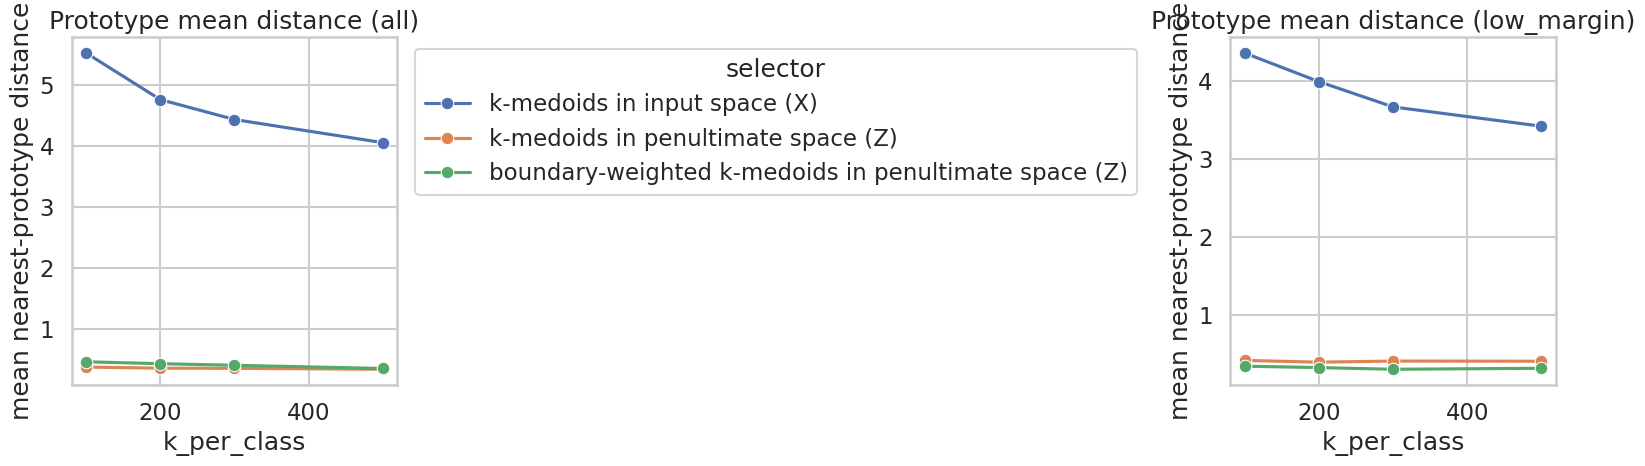

In [6]:
compression_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            compression_rows.extend(_prototype_distance_rows(bundle, selection_method, k))

compression_df = pd.DataFrame(compression_rows)
compression_overall = compression_df[compression_df['class_label'].eq('overall')].copy()
display(
    compression_overall.sort_values(['dataset', 'subset', 'k_per_class', 'selection_method'])[
        ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'subset', 'mean_distance', 'median_distance', 'p90_distance', 'p95_distance']
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for subset_name, ax in zip(['all', 'low_margin'], axes):
    plot_df = compression_overall[compression_overall['subset'] == subset_name]
    sns.lineplot(data=plot_df, x='k_per_class', y='mean_distance', hue='selection_label', marker='o', ax=ax)
    ax.set_title(f'Prototype mean distance ({subset_name})')
    ax.set_ylabel('mean nearest-prototype distance')
    if ax is not axes[0]:
        ax.legend_.remove()
axes[0].legend(title='selector', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()


## 3. Certified Atlas Coverage And Overlap

The atlas is always built in the original input space from the selected training points. This section checks whether the boundary-biased latent selector preserves or erodes the sampled certified support compared with the two unweighted baselines.


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:12<00:00,  6.05s/it]


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,n_covered,coverage_rate,build_time_s,n_selected_total
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,296,0.037000,2.680381,200
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,8000,159,0.019875,2.427797,200
26,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,100,8000,176,0.022000,2.502166,200
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,487,0.060875,4.740441,400
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,8000,254,0.031750,4.848729,400
29,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,200,8000,276,0.034500,4.846999,400
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,565,0.070625,7.215857,600
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,8000,340,0.042500,7.207939,600
32,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,300,8000,412,0.051500,7.365858,600
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,8000,779,0.097375,12.268166,1000


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,coverage_rate,multi_cover_rate,mean_cover_count,mean_cover_count_if_covered,mean_overlap_excess,build_time_s,n_selected_total
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,0.037000,0.007000,0.055750,1.506757,0.018750,2.680381,200
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,8000,0.019875,0.000750,0.020750,1.044025,0.000875,2.427797,200
26,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,100,8000,0.022000,0.002125,0.024625,1.119318,0.002625,2.502166,200
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,0.060875,0.014875,0.132000,2.168378,0.071125,4.740441,400
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,8000,0.031750,0.004375,0.038250,1.204724,0.006500,4.848729,400
29,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,200,8000,0.034500,0.007000,0.047125,1.365942,0.012625,4.846999,400
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,0.070625,0.020250,0.176500,2.499115,0.105875,7.215857,600
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,8000,0.042500,0.008125,0.057625,1.355882,0.015125,7.207939,600
32,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,overall,300,8000,0.051500,0.010500,0.068500,1.330097,0.017000,7.365858,600
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,8000,0.097375,0.029625,0.246000,2.526316,0.148625,12.268166,1000


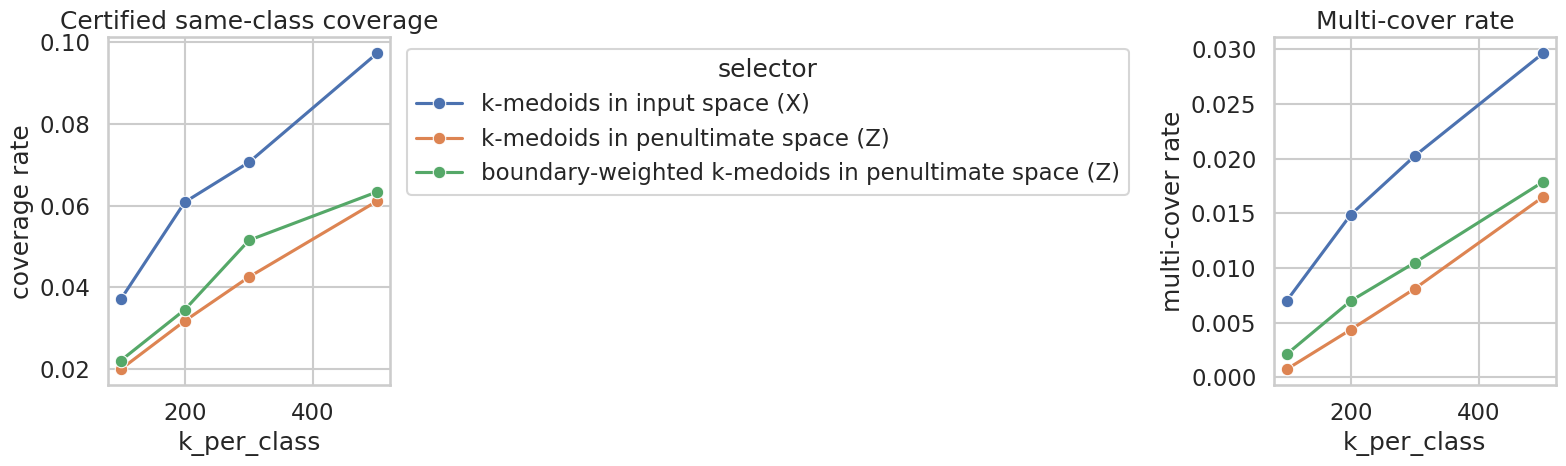

In [7]:
coverage_rows = []
overlap_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            coverage_rows.extend(_coverage_rows(bundle, selection_method, k))
            overlap_rows.extend(_overlap_rows(bundle, selection_method, k))

coverage_df = pd.DataFrame(coverage_rows)
overlap_df = pd.DataFrame(overlap_rows)
coverage_overall = coverage_df[coverage_df['class_label'].eq('overall')].copy()
overlap_overall = overlap_df[overlap_df['class_label'].eq('overall')].copy()

display(coverage_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))
display(overlap_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
sns.lineplot(data=coverage_overall, x='k_per_class', y='coverage_rate', hue='selection_label', marker='o', ax=axes[0])
axes[0].set_title('Certified same-class coverage')
axes[0].set_ylabel('coverage rate')

sns.lineplot(data=overlap_overall, x='k_per_class', y='multi_cover_rate', hue='selection_label', marker='o', ax=axes[1])
axes[1].set_title('Multi-cover rate')
axes[1].set_ylabel('multi-cover rate')
axes[1].legend_.remove()
axes[0].legend(title='selector', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()


## 4. Pilot Query Diagnostics

A fixed small pilot query set is used to compare end-to-end CertCF behavior under the three anchor-selection rules. This is still a pilot view, not the final benchmark evidence, but it is useful for checking whether the weighted latent selector changes the proximity / runtime trade-off in the expected direction.


/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,dataset,selection_method,selection_label,selection_space,k_per_class,success_rate,mean_distance,median_distance,mean_query_time_ms,median_query_time_ms,build_time_s
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.0,9.165162,9.307326,1284.944376,680.205600,2.680381
4,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,1.0,8.930613,9.152910,998.552554,617.431695,2.427797
8,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,100,1.0,8.733973,9.582182,808.896980,592.188567,2.502166
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.0,8.962666,9.445743,1583.406701,1365.996249,4.740441
5,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,1.0,9.425369,10.109045,1210.971343,1179.968015,4.848729
9,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,200,1.0,8.070296,7.976920,1372.211967,1127.118518,4.846999
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.0,8.636928,9.164355,2654.899284,2158.953776,7.215857
6,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,1.0,9.208049,10.267728,1628.801745,1733.890333,7.207939
10,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,300,1.0,7.935070,7.976920,1679.316867,1477.023444,7.365858
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1.0,7.996639,8.313503,2407.373029,2524.640102,12.268166


/tmp/ipykernel_303893/2779357609.py:38: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


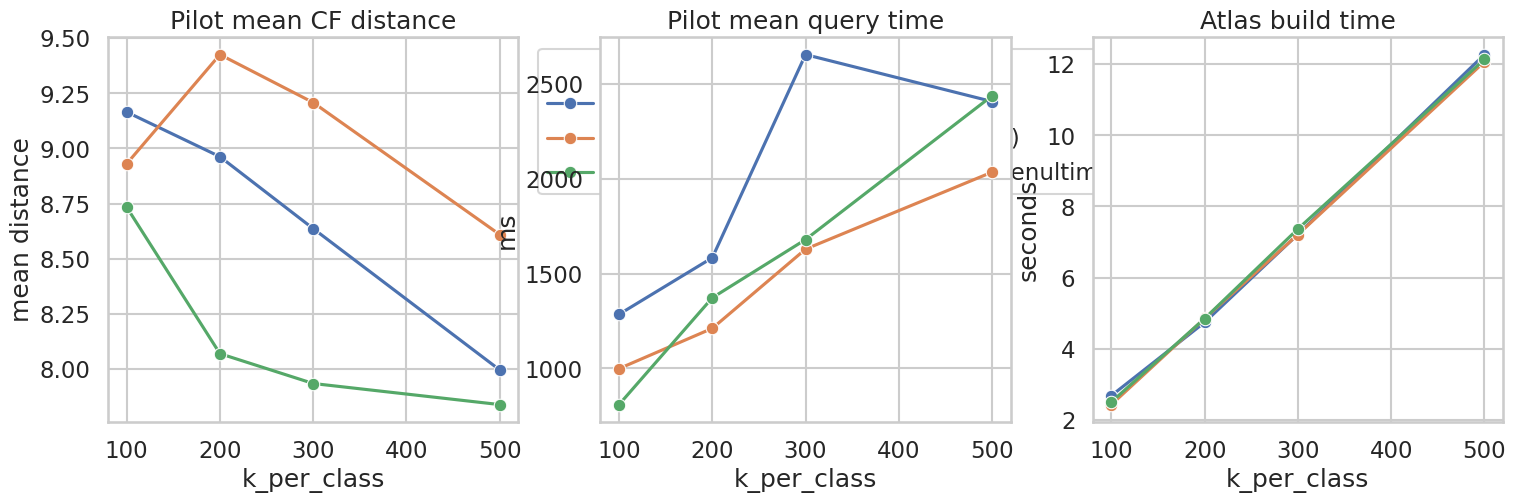

In [8]:
pilot_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            pilot_rows.extend(_pilot_query_rows(bundle, selection_method, k))

pilot_df = pd.DataFrame(pilot_rows)
pilot_summary = (
    pilot_df.groupby(['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'], as_index=False)
    .agg(
        success_rate=('success', 'mean'),
        mean_distance=('distance', 'mean'),
        median_distance=('distance', 'median'),
        mean_l1_distance=('l1_distance', 'mean'),
        median_l1_distance=('l1_distance', 'median'),
        mean_l2_distance=('l2_distance', 'mean'),
        median_l2_distance=('l2_distance', 'median'),
        mean_query_time_ms=('query_time_ms', 'mean'),
        median_query_time_ms=('query_time_ms', 'median'),
        build_time_s=('build_time_s', 'mean'),
    )
)

display(pilot_summary.sort_values(['dataset', 'k_per_class', 'selection_method']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
sns.lineplot(data=pilot_summary, x='k_per_class', y='mean_distance', hue='selection_label', marker='o', ax=axes[0])
axes[0].set_title('Pilot mean CF distance')
axes[0].set_ylabel('mean distance')

sns.lineplot(data=pilot_summary, x='k_per_class', y='mean_query_time_ms', hue='selection_label', marker='o', ax=axes[1])
axes[1].set_title('Pilot mean query time')
axes[1].set_ylabel('ms')

sns.lineplot(data=pilot_summary, x='k_per_class', y='build_time_s', hue='selection_label', marker='o', ax=axes[2])
axes[2].set_title('Atlas build time')
axes[2].set_ylabel('seconds')

for ax in axes[1:]:
    ax.legend_.remove()
axes[0].legend(title='selector', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()


## 5. Side-By-Side Comparison Tables

This section merges the main diagnostics into one table, then reports deltas versus the input-space baseline `kmedoids_x`. The key comparison for the new idea is whether `weighted_kmedoids_z` improves boundary coverage and pilot proximity without paying too much in certified support or query time.


In [9]:
metric_table = _make_metric_table(
    selection_overall=selection_overall,
    compression_overall=compression_overall,
    coverage_overall=coverage_overall,
    overlap_overall=overlap_overall,
    pilot_summary=pilot_summary,
)

delta_table = _make_delta_table(metric_table)

display(metric_table.sort_values(['dataset', 'k_per_class', 'selection_method']))
display(delta_table.sort_values(['dataset', 'k_per_class', 'selection_method_variant']))


,dataset,selection_method,selection_label,selection_space,k_per_class,selected_margin_mean,selected_margin_median,selected_boundary_score_mean,selected_boundary_score_median,selected_boundary_score_p90,...,p95_distance_low_margin,mean_distance_all,mean_distance_low_margin,success_rate,pilot_mean_distance,pilot_median_distance,mean_query_time_ms,median_query_time_ms,build_time_s,boundary_share
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.426396,1.011643,0.576186,0.574682,0.883009,...,10.154889,5.525353,4.352805,1.0,9.165162,9.307326,1284.944376,680.205600,2.680381,0.445000
4,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,2.174452,1.706281,0.458792,0.454514,0.602518,...,0.761465,0.372983,0.420901,1.0,8.930613,9.152910,998.552554,617.431695,2.427797,0.085000
8,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,100,1.402810,0.981280,0.625641,0.632440,0.799938,...,0.627904,0.459835,0.346789,1.0,8.733973,9.582182,808.896980,592.188567,2.502166,0.450000
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.488710,1.011519,0.565539,0.557554,0.873250,...,9.664501,4.762373,3.987674,1.0,8.962666,9.445743,1583.406701,1365.996249,4.740441,0.442500
5,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,2.082378,1.526386,0.455591,0.452097,0.544357,...,0.755171,0.354265,0.398179,1.0,9.425369,10.109045,1210.971343,1179.968015,4.848729,0.052500
9,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,200,1.318814,1.063130,0.617541,0.624004,0.743869,...,0.616693,0.428122,0.328947,1.0,8.070296,7.976920,1372.211967,1127.118518,4.846999,0.445000
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.420318,0.996046,0.581932,0.581143,0.882315,...,9.066442,4.435876,3.664643,1.0,8.636928,9.164355,2654.899284,2158.953776,7.215857,0.461667
6,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,2.056416,1.610333,0.452552,0.450433,0.517520,...,0.765804,0.351913,0.412534,1.0,9.208049,10.267728,1628.801745,1733.890333,7.207939,0.040000
10,adult,weighted_kmedoids_z,boundary-weighted k-medoids in penultimate spa...,latent_space_weighted,300,1.307165,1.000481,0.602866,0.607777,0.751015,...,0.558690,0.402325,0.307330,1.0,7.935070,7.976920,1679.316867,1477.023444,7.365858,0.373333
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1.451220,0.996452,0.576428,0.581656,0.882442,...,8.573584,4.056613,3.418039,1.0,7.996639,8.313503,2407.373029,2524.640102,12.268166,0.464000


,dataset,selection_method_baseline,selection_label_baseline,selection_space_baseline,k_per_class,selected_margin_mean_baseline,selected_margin_median_baseline,selected_boundary_score_mean_baseline,selected_boundary_score_median_baseline,selected_boundary_score_p90_baseline,...,delta_mean_distance_all,delta_p95_distance_all,delta_mean_distance_low_margin,delta_p95_distance_low_margin,delta_success_rate,delta_pilot_mean_distance,delta_pilot_median_distance,delta_mean_query_time_ms,delta_median_query_time_ms,delta_build_time_s
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.426396,1.011643,0.576186,0.574682,0.883009,...,-5.152370,-10.148658,-3.931904,-9.393424,0.0,-0.234549,-0.154416,-286.391822,-62.773905,-0.252584
1,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.426396,1.011643,0.576186,0.574682,0.883009,...,-5.065518,-9.872030,-4.006016,-9.526985,0.0,-0.431189,0.274856,-476.047397,-88.017033,-0.178216
2,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.488710,1.011519,0.565539,0.557554,0.873250,...,-4.408107,-9.295337,-3.589495,-8.909330,0.0,0.462703,0.663302,-372.435358,-186.028234,0.108288
3,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.488710,1.011519,0.565539,0.557554,0.873250,...,-4.334250,-8.977358,-3.658727,-9.047809,0.0,-0.892370,-1.468823,-211.194733,-238.877731,0.106558
4,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.420318,0.996046,0.581932,0.581143,0.882315,...,-4.083962,-8.894864,-3.252109,-8.300638,0.0,0.571121,1.103373,-1026.097539,-425.063443,-0.007918
5,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.420318,0.996046,0.581932,0.581143,0.882315,...,-4.033550,-8.575243,-3.357313,-8.507752,0.0,-0.701859,-1.187435,-975.582417,-681.930332,0.150000
6,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1.451220,0.996452,0.576428,0.581656,0.882442,...,-3.719977,-8.336277,-3.007533,-7.822859,0.0,0.613283,0.935144,-372.578305,-413.955512,-0.202356
7,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1.451220,0.996452,0.576428,0.581656,0.882442,...,-3.707138,-8.233020,-3.097613,-7.992323,0.0,-0.157074,-0.041653,29.870647,-506.974211,-0.134729


## 6. Anchor Visualization

The final view overlays the selected anchors on a sampled subset of the Adult support in both input PCA and latent PCA. This makes it easy to see whether the weighted latent selector is visibly concentrating anchors closer to the class interface in latent space.


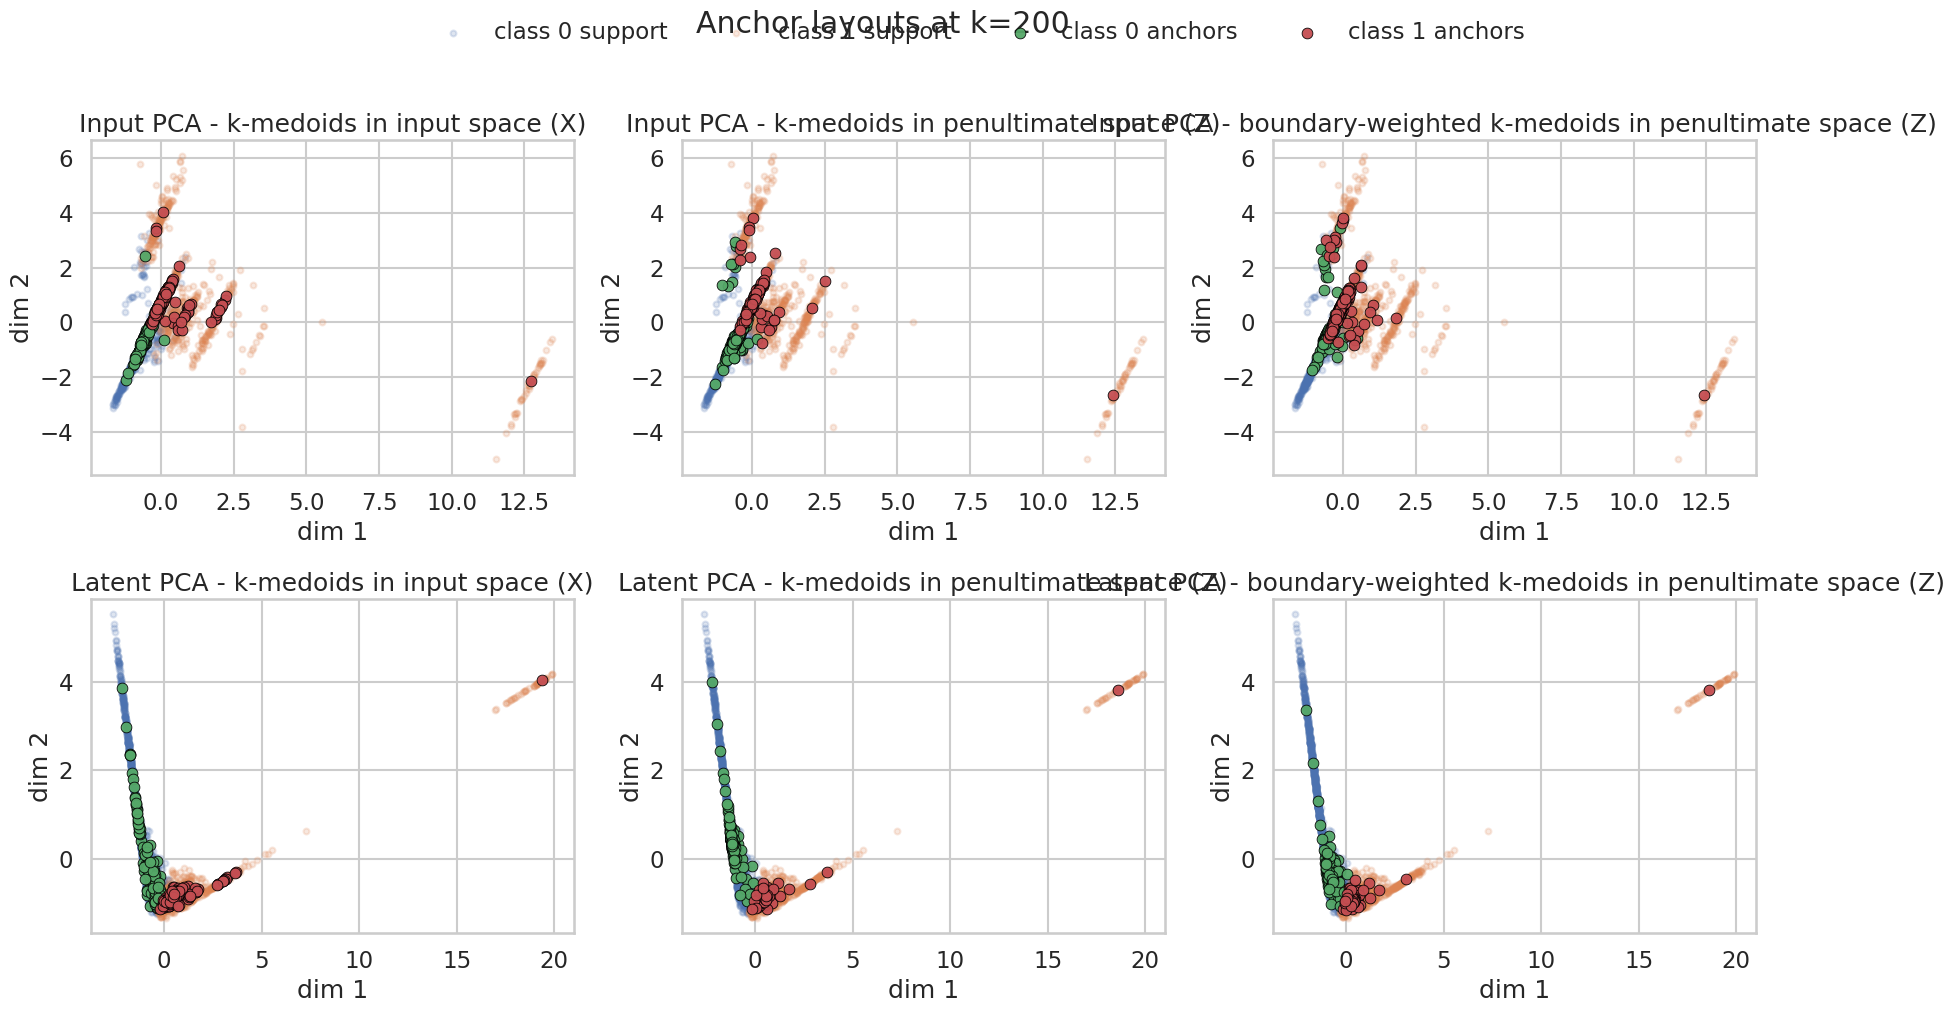

In [10]:
for dataset_name, bundle in bundles.items():
    _plot_anchor_views(bundle, visual_k=VISUAL_K)


## 7. Pilot L1/L2 Proximity Distributions

The aggregate means above hide whether a selector improves the full distribution or only a few easy queries. These histograms compare successful pilot counterfactuals by `k_per_class`, selector, and proximity metric.


In [ ]:
required_proximity_cols = {'l1_distance', 'l2_distance'}
missing = required_proximity_cols.difference(pilot_df.columns)
if missing:
    print('pilot_df does not yet contain L1/L2 proximity columns; rebuilding pilot_df now...')
    pilot_rows = []
    for dataset_name, bundle in bundles.items():
        for selection_method in ANCHOR_SELECTION_METHODS:
            for k in K_GRID:
                pilot_rows.extend(_pilot_query_rows(bundle, selection_method, k))
    pilot_df = pd.DataFrame(pilot_rows)
    missing = required_proximity_cols.difference(pilot_df.columns)
    if missing:
        raise ValueError(
            'Still missing L1/L2 proximity columns after rebuilding. Re-run the cell that defines '
            '`_pilot_query_rows(...)` first, then re-run this cell. '
            f'Missing: {sorted(missing)}'
        )

pilot_success_df = pilot_df.loc[pilot_df['success']].copy()
if pilot_success_df.empty:
    raise ValueError('No successful pilot counterfactuals available to plot.')

FIGURES_DIR = ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

metrics = [
    ('l1_distance', 'L1 proximity'),
    ('l2_distance', 'L2 proximity'),
]

for dataset_name, dataset_df in pilot_success_df.groupby('dataset'):
    k_values = sorted(dataset_df['k_per_class'].dropna().unique())
    fig, axes = plt.subplots(
        len(k_values),
        len(metrics),
        figsize=(14, 3.2 * len(k_values)),
        squeeze=False,
        sharey=False,
    )

    for row_idx, k in enumerate(k_values):
        k_df = dataset_df.loc[dataset_df['k_per_class'] == k]
        for col_idx, (metric, label) in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            sns.histplot(
                data=k_df,
                x=metric,
                hue='selection_label',
                bins=20,
                stat='density',
                common_norm=False,
                element='step',
                fill=True,
                alpha=0.30,
                ax=ax,
            )
            ax.set_title(f'{dataset_name} | k={int(k)} | {label}')
            ax.set_xlabel(label)
            ax.set_ylabel('density')

    fig.suptitle(f'Pilot counterfactual proximity distributions: {dataset_name}', y=1.02)
    fig.tight_layout()
    out_path = FIGURES_DIR / f'certcf_boundary_pilot_{dataset_name}_l1_l2_histograms.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')


pilot_df does not yet contain L1/L2 proximity columns; rebuilding pilot_df now...


/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


## 8. Notes

- `weighted_kmedoids_z` is intentionally a **notebook-only exploratory selector** for now.
- It uses a weighted latent-space CLARA-style heuristic rather than a custom exact weighted `k`-medoids solver.
- If the method looks promising here, the next step would be to formalize the selector inside the benchmark-facing CertCF code path and validate it with the full benchmark workflow.
